In [1]:
#here we are going to make  a simple workflow to see teh working of the persistence in the langgraph 
#persistence is use to store the state of the workflow 
#it is use to save and restore the state of the workflow over a time instance 


#NOTE:- In the langgraph the persistence is done by the checkpointers 


In [2]:
#we required the llm  model lets add it in the workflow 
#here we are usign the groq's llm model 
from langchain_groq import ChatGroq
from dotenv import load_dotenv 
load_dotenv() 
from langgraph.checkpoint.memory import InMemorySaver 

llm=ChatGroq(model='Llama3-70b-8192') 

In [3]:
llm.invoke('hello, how are you?').content

"Hello! I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?"

In [4]:
from langgraph.graph import StateGraph, START , END 

from langgraph.checkpoint.memory import MemorySaver 


In [5]:
#lets firstly define the state for our workflow 
from typing import TypedDict 
class Joke_gen(TypedDict):
    topic: str 
    generated_joke: str 
    explanation: str 
    
    
    
    

In [6]:
#lets define our graph and make his nodes and edges 
graph=StateGraph(Joke_gen) 

In [7]:
def Joke_generation(state: Joke_gen)-> Joke_gen: 
    topic=state['topic'] 
    prompt=f'Generate a joke for a given topic -- {topic}' 
    joke=llm.invoke(prompt).content 
    return {'generated_joke':joke} 


#for the explanation 
def Joke_explanation(state: Joke_gen)-> Joke_gen: 
    joke=state['generated_joke'] 
    prompt=f'Explain the given joke in detail --{joke}' 
    explanation=llm.invoke(prompt).content 
    return {'explanation':explanation}

In [8]:
#lets add the nodes to the graph 

#first for the generation of the joke 
graph.add_node('generate_joke',Joke_generation) 
graph.add_node('joke_explanation',Joke_explanation) 



#lets add the edges to the graph 
graph.add_edge(START,'generate_joke') 
graph.add_edge('generate_joke','joke_explanation') 
graph.add_edge('joke_explanation',END) 

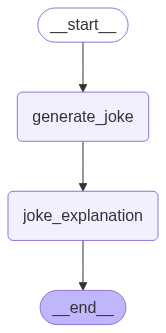

In [9]:
#lets check our workflow 

#lets make a object of the memory saver 
checkpointer=InMemorySaver() 

#we have to pass it while the compilation of our workflow 
workflow=graph.compile(checkpointer=checkpointer) 
workflow

In [10]:
#lets check the workflow with the initial state 
initial_state={'topic':'Python'}

#after providing the checkpointer we have to pass the configuration while invoking 
configuration={'configurable':{'thread_id':'1'}}

final_state=workflow.invoke(initial_state,config=configuration) 
final_state

{'topic': 'Python',
 'generated_joke': "Here's a Python joke:\n\nWhy do Python programmers prefer dark mode?\n\nBecause light attracts bugs.\n\n(get it?)",
 'explanation': 'A clever joke!\n\nThis joke plays on a double meaning of the word "bugs" and is a play on words, making it a clever pun. Here\'s a breakdown of the joke:\n\n**Setup:** The joke starts by asking why Python programmers prefer dark mode. This sets up the expectation that the punchline will be a reason related to programming or the Python language.\n\n**Punchline:** The punchline is "Because light attracts bugs." This is where the joke gets clever.\n\n**Double meaning of "bugs":** In programming, a "bug" is an error or a flaw in the code that causes it to behave unexpectedly. This is the first meaning of "bugs" that comes to mind when thinking about programming.\n\n**The pun:** However, "bugs" also refers to insects, such as mosquitoes or flies, that are attracted to light. This is the second meaning of "bugs" that the 

In [11]:
# lets access the State 
print(workflow.get_state(config=configuration))
#this above funciton will show the values of the state at current time instance 

StateSnapshot(values={'topic': 'Python', 'generated_joke': "Here's a Python joke:\n\nWhy do Python programmers prefer dark mode?\n\nBecause light attracts bugs.\n\n(get it?)", 'explanation': 'A clever joke!\n\nThis joke plays on a double meaning of the word "bugs" and is a play on words, making it a clever pun. Here\'s a breakdown of the joke:\n\n**Setup:** The joke starts by asking why Python programmers prefer dark mode. This sets up the expectation that the punchline will be a reason related to programming or the Python language.\n\n**Punchline:** The punchline is "Because light attracts bugs." This is where the joke gets clever.\n\n**Double meaning of "bugs":** In programming, a "bug" is an error or a flaw in the code that causes it to behave unexpectedly. This is the first meaning of "bugs" that comes to mind when thinking about programming.\n\n**The pun:** However, "bugs" also refers to insects, such as mosquitoes or flies, that are attracted to light. This is the second meaning 

In [12]:
#LETS SEE THE HISTORY MEANS THE CHANGE IN THE STATE OVER THE WORKFLOW EXECUTION 
# NOTE: VALUES ARE STORED IN THE CHRONOLOGICAL ORDER MEANS THE LATEST UPDATE WILL BE AT THE TOP 
history=workflow.get_state_history(config=configuration) 
list(history)


[StateSnapshot(values={'topic': 'Python', 'generated_joke': "Here's a Python joke:\n\nWhy do Python programmers prefer dark mode?\n\nBecause light attracts bugs.\n\n(get it?)", 'explanation': 'A clever joke!\n\nThis joke plays on a double meaning of the word "bugs" and is a play on words, making it a clever pun. Here\'s a breakdown of the joke:\n\n**Setup:** The joke starts by asking why Python programmers prefer dark mode. This sets up the expectation that the punchline will be a reason related to programming or the Python language.\n\n**Punchline:** The punchline is "Because light attracts bugs." This is where the joke gets clever.\n\n**Double meaning of "bugs":** In programming, a "bug" is an error or a flaw in the code that causes it to behave unexpectedly. This is the first meaning of "bugs" that comes to mind when thinking about programming.\n\n**The pun:** However, "bugs" also refers to insects, such as mosquitoes or flies, that are attracted to light. This is the second meaning

In [13]:
#lets make a new state and inovke the workflow again 
configuration_2={'configurable':{'thread_id':'2'}}
initial_state_2={'topic':'java'}
final_state_2=workflow.invoke(initial_state_2,config=configuration_2)

In [14]:
final_state_2

{'topic': 'java',
 'generated_joke': "A joke about Java! Here's one:\n\nWhy did the Java programmer quit his job?\n\nBecause he didn't get arrays! (get a raise)\n\nHope that one compiled correctly and executed a laugh from you!",
 'explanation': 'A clever joke about Java!\n\nLet\'s break down the joke step by step:\n\n**The setup:** "Why did the Java programmer quit his job?" - This is a classic format for a joke, setting up a situation and asking a question that implies there\'s a punchline coming.\n\n**The punchline:** "Because he didn\'t get arrays!" - This is where the joke relies on a play on words. In Java, an "array" is a data structure that stores a collection of elements of the same data type. It\'s a fundamental concept in programming.\n\n**The wordplay:** The joke is saying that the Java programmer quit his job because he "didn\'t get arrays." But "get arrays" sounds similar to "get a raise." A "raise" is a salary increase, which is a common reason why people might quit thei

In [15]:
#lets see the history again 
#lets check the state values 
workflow.get_state(config=configuration_2)

StateSnapshot(values={'topic': 'java', 'generated_joke': "A joke about Java! Here's one:\n\nWhy did the Java programmer quit his job?\n\nBecause he didn't get arrays! (get a raise)\n\nHope that one compiled correctly and executed a laugh from you!", 'explanation': 'A clever joke about Java!\n\nLet\'s break down the joke step by step:\n\n**The setup:** "Why did the Java programmer quit his job?" - This is a classic format for a joke, setting up a situation and asking a question that implies there\'s a punchline coming.\n\n**The punchline:** "Because he didn\'t get arrays!" - This is where the joke relies on a play on words. In Java, an "array" is a data structure that stores a collection of elements of the same data type. It\'s a fundamental concept in programming.\n\n**The wordplay:** The joke is saying that the Java programmer quit his job because he "didn\'t get arrays." But "get arrays" sounds similar to "get a raise." A "raise" is a salary increase, which is a common reason why peo

In [16]:
list(workflow.get_state_history(config=configuration_2))

[StateSnapshot(values={'topic': 'java', 'generated_joke': "A joke about Java! Here's one:\n\nWhy did the Java programmer quit his job?\n\nBecause he didn't get arrays! (get a raise)\n\nHope that one compiled correctly and executed a laugh from you!", 'explanation': 'A clever joke about Java!\n\nLet\'s break down the joke step by step:\n\n**The setup:** "Why did the Java programmer quit his job?" - This is a classic format for a joke, setting up a situation and asking a question that implies there\'s a punchline coming.\n\n**The punchline:** "Because he didn\'t get arrays!" - This is where the joke relies on a play on words. In Java, an "array" is a data structure that stores a collection of elements of the same data type. It\'s a fundamental concept in programming.\n\n**The wordplay:** The joke is saying that the Java programmer quit his job because he "didn\'t get arrays." But "get arrays" sounds similar to "get a raise." A "raise" is a salary increase, which is a common reason why pe

In [17]:
#lets also see our previous state's history 
list(workflow.get_state_history(config=configuration))
#as you can see it is working as a database for storing the different states of the workflow 

[StateSnapshot(values={'topic': 'Python', 'generated_joke': "Here's a Python joke:\n\nWhy do Python programmers prefer dark mode?\n\nBecause light attracts bugs.\n\n(get it?)", 'explanation': 'A clever joke!\n\nThis joke plays on a double meaning of the word "bugs" and is a play on words, making it a clever pun. Here\'s a breakdown of the joke:\n\n**Setup:** The joke starts by asking why Python programmers prefer dark mode. This sets up the expectation that the punchline will be a reason related to programming or the Python language.\n\n**Punchline:** The punchline is "Because light attracts bugs." This is where the joke gets clever.\n\n**Double meaning of "bugs":** In programming, a "bug" is an error or a flaw in the code that causes it to behave unexpectedly. This is the first meaning of "bugs" that comes to mind when thinking about programming.\n\n**The pun:** However, "bugs" also refers to insects, such as mosquitoes or flies, that are attracted to light. This is the second meaning

# Benefits of the persistence

In [18]:
# 1. SHORTTERM MEMORY 
# 2. FAULT TOLERANCE
# 3. HUMAN IN THE LOOP
# 4. TIME TRAVEL  


# 1. IN SHORTTERM MEMEORY WE PROVIDE THE PREVIOUS ALL THE CONVERSATION TO THE LLM SO THAT IT HAVE
# KNOWLEDGE ABOUT THE PREVIOUS CONVERSATION AND IT CAN GIVE THE BETTER RESPONSE.
# # AS WE ALREADY DONE IN OUR PREVIOUS WORKFLOW OF THE BASIC CHATBOT 

In [19]:
# 2. FAULT TOLERANCE- WHEN OUR WORKFLOW GETS CRASHED ON ANY OF THE STEP OR NODE THEN WE CAN RESUME OR RESTORE 
# THE WORKFLOW FROM THE SAME NODE OR STATE
# FOR UNDERSTANDING THIS I HAVE IMPLEMENTED AN EXAMPLE IN THE FILE NAMED 'fault_tolerance_using_persistence.ipynb'

In [20]:
#3. Human in the loop - Here we want that the next part of teh workflow will executed only if the human approves it 



In [21]:
#4. Time travel - Here we can replay the execution of the workflow
# means from any point i can again run the remaining workflow of any state 


In [22]:
#now lets first run our workflow with a new topic for the time travel ability of the langgraph using persistence 
initial_state3={'topic':'c++'} 
config3={'configurable':{'thread_id':'3'}} 
final_state_3=workflow.invoke(initial_state3,config=config3)
list(workflow.get_state_history(config=config3))

[StateSnapshot(values={'topic': 'c++', 'generated_joke': "A joke about C++! Here's one:\n\nWhy did the C++ program go to therapy?\n\nBecause it had a lot of `pointer` issues and was struggling to `delete` its problems! But in the end, it just needed to `reallocate` its priorities and `new` ways of thinking.\n\nHope that one compiled successfully and executed a laugh!", 'explanation': 'What a great joke!\n\nThis joke is a play on words, using C++ programming concepts to create a pun-filled joke about a program going to therapy. Let\'s break it down:\n\n**"Why did the C++ program go to therapy?"**\n\nThis is the setup for the joke, establishing the premise that a C++ program (a type of computer program written in the C++ language) is seeking therapy, which is a human concept. This already creates a humorous mismatch between a computer program and a human-like situation.\n\n**"Because it had a lot of `pointer` issues..."**\n\nIn C++, a `pointer` is a variable that holds a memory address a

In [ ]:
#lets see the timetravel 

#so here we are again generating the joke for the given topic c++ but 
#now we are using the topic of previous state and after that the workflow executes


#here we have to simply add the checkpoint_id of the particular state in the workflow 

workflow.get_state({"configurable": {"thread_id": "3", "checkpoint_id": "1f07f440-7e3f-6327-8000-a609ff06af5f"}})

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '3', 'checkpoint_id': '1f079fa6-a336-644a-8000-03e82450ed93'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

In [30]:
#now lets execute from teh above checkpoint 
workflow.invoke(None, config={"configurable": {"thread_id": "3", "checkpoint_id": "1f07f440-7e3f-6327-8000-a609ff06af5f"}})

{'topic': 'c++',
 'generated_joke': "A joke about C++! Here's one:\n\nWhy did the C++ program go to therapy?\n\nBecause it had a lot of `pointer` issues and was struggling to `delete` its problems! But in the end, it just needed to `reallocate` its priorities and `new` ways of thinking.\n\nHope that one compiled successfully and executed a laugh!",
 'explanation': 'What a great joke!\n\nThis joke is a play on words, using C++ programming concepts to create a pun-filled joke about a program going to therapy. Let\'s break it down:\n\n**"Why did the C++ program go to therapy?"**\n\nThis is the setup for the joke, establishing the premise that a C++ program (a type of computer program written in the C++ language) is seeking therapy, which is a human concept. This already creates a humorous mismatch between a computer program and a human-like situation.\n\n**"Because it had a lot of `pointer` issues..."**\n\nIn C++, a `pointer` is a variable that holds a memory address as its value. It\'s a

In [32]:
#now lets again see the state history 
list(workflow.get_state_history(config=config3))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f07f443-ce93-60a0-8000-86f12383b97d'}}, metadata={'thread_id': '3', 'checkpoint_id': '1f079fa6-a336-644a-8000-03e82450ed93', 'checkpoint_ns': '', 'source': 'update', 'step': 0, 'writes': {'__start__': {'topic': 'samosa'}}, 'parents': {}}, created_at='2025-08-22T10:39:10.490435+00:00', parent_config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f079fa6-a336-644a-8000-03e82450ed93'}}, tasks=(PregelTask(id='aa0e68e7-9e10-00a3-5c9b-f84b26198572', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'c++', 'generated_joke': "A joke about C++! Here's one:\n\nWhy did the C++ program go to therapy?\n\nBecause it had a lot of `pointer` issues and was struggling to `delete` its problems! But in the end, it 

In [31]:
#Note: Here we can also change the values of the state at a particular node or checkpoing using the persistence 
#lets see that and execute the remaining workflow 
#here we are providing the checkpoint_id after the topic provided node 
workflow.update_state({'configurable':{'thread_id':'3','checkpoint_id':'1f079fa6-a336-644a-8000-03e82450ed93','checkpoint_ns':''}},{'topic':'samosa'}) 

{'configurable': {'thread_id': '3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f07f443-ce93-60a0-8000-86f12383b97d'}}

In [ ]:
list(workflow.get_state(config=configuration_2))

[{'topic': 'java',
  'generated_joke': "A joke about Java! Here's one:\n\nWhy did the Java programmer quit his job?\n\nBecause he didn't get arrays! (get a raise)\n\nHope that one compiled correctly and executed a laugh from you!",
  'explanation': 'A clever joke about Java!\n\nLet\'s break down the joke step by step:\n\n**The setup:** "Why did the Java programmer quit his job?" - This is a classic format for a joke, setting up a situation and asking a question that implies there\'s a punchline coming.\n\n**The punchline:** "Because he didn\'t get arrays!" - This is where the joke relies on a play on words. In Java, an "array" is a data structure that stores a collection of elements of the same data type. It\'s a fundamental concept in programming.\n\n**The wordplay:** The joke is saying that the Java programmer quit his job because he "didn\'t get arrays." But "get arrays" sounds similar to "get a raise." A "raise" is a salary increase, which is a common reason why people might quit t

In [ ]:
#now lets execute from this particular place by providing the checkpoint_id and state as None 
workflow.invoke(None, config={"configurable": {"thread_id": "3", "checkpoint_id": "1f079fbc-5c29-67af-8001-8575fe16faac"}})

{'topic': 'samosa',
 'generated_joke': 'A samosa joke! Here\'s one:\n\nWhy did the samosa go to therapy?\n\nBecause it was feeling a little "crusty" and was struggling to "wrap" its head around its feelings!',
 'explanation': 'What a delightful joke! Let\'s break it down and explore the clever wordplay behind it.\n\nThe joke is a play on words, using puns to create a humorous connection between the concept of a samosa (a popular Indian snack) and the idea of going to therapy. Here\'s a step-by-step explanation:\n\n**Setup:** The joke starts by asking, "Why did the samosa go to therapy?" This is a classic joke setup, where the listener is expecting a punchline that will explain why a samosa, an inanimate object, would need therapy.\n\n**Punchline:** The punchline is: "Because it was feeling a little \'crusty\' and was struggling to \'wrap\' its head around its feelings!"\n\n**Wordplay:**\n\n1. **"Crusty":** In this context, "crusty" has a double meaning. In baking, a crusty texture refe

In [ ]:
list(workflow.get_state_history(config=config3))

[StateSnapshot(values={'topic': 'samosa', 'generated_joke': 'A samosa joke! Here\'s one:\n\nWhy did the samosa go to therapy?\n\nBecause it was feeling a little "crusty" and was struggling to "wrap" its head around its feelings!', 'explanation': 'What a delightful joke! Let\'s break it down and explore the clever wordplay behind it.\n\nThe joke is a play on words, using puns to create a humorous connection between the concept of a samosa (a popular Indian snack) and the idea of going to therapy. Here\'s a step-by-step explanation:\n\n**Setup:** The joke starts by asking, "Why did the samosa go to therapy?" This is a classic joke setup, where the listener is expecting a punchline that will explain why a samosa, an inanimate object, would need therapy.\n\n**Punchline:** The punchline is: "Because it was feeling a little \'crusty\' and was struggling to \'wrap\' its head around its feelings!"\n\n**Wordplay:**\n\n1. **"Crusty":** In this context, "crusty" has a double meaning. In baking, a

: 